In [1]:
# Unsupervised Learning for Kidney Disease Dataset

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("kidney_disease.csv")

# Keep only numeric columns
df = df.select_dtypes(include=['int64', 'float64'])

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(df)

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
df['Cluster'] = clusters

print(df.head())

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Kidney Disease Clustering")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'kidney_disease.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("kidney_disease_dataset.csv")
df.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


In [5]:
print(df.shape)
print(df.columns)
df.info()

(20538, 43)
Index(['Age of the patient', 'Blood pressure (mm/Hg)',
       'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine',
       'Red blood cells in urine', 'Pus cells in urine',
       'Pus cell clumps in urine', 'Bacteria in urine',
       'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)',
       'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)',
       'Potassium level (mEq/L)', 'Hemoglobin level (gms)',
       'Packed cell volume (%)', 'White blood cell count (cells/cumm)',
       'Red blood cell count (millions/cumm)', 'Hypertension (yes/no)',
       'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)',
       'Appetite (good/poor)', 'Pedal edema (yes/no)', 'Anemia (yes/no)',
       'Estimated Glomerular Filtration Rate (eGFR)',
       'Urine protein-to-creatinine ratio', 'Urine output (ml/day)',
       'Serum albumin level', 'Cholesterol level',
       'Parathyroid hormone (PTH) level', 'Serum calcium level',
       'Serum phosphate level'

In [6]:
print(df.isnull().sum())

Age of the patient                             0
Blood pressure (mm/Hg)                         0
Specific gravity of urine                      0
Albumin in urine                               0
Sugar in urine                                 0
Red blood cells in urine                       0
Pus cells in urine                             0
Pus cell clumps in urine                       0
Bacteria in urine                              0
Random blood glucose level (mg/dl)             0
Blood urea (mg/dl)                             0
Serum creatinine (mg/dl)                       0
Sodium level (mEq/L)                           0
Potassium level (mEq/L)                        0
Hemoglobin level (gms)                         0
Packed cell volume (%)                         0
White blood cell count (cells/cumm)            0
Red blood cell count (millions/cumm)           0
Hypertension (yes/no)                          0
Diabetes mellitus (yes/no)                     0
Coronary artery dise

In [7]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

print(df_numeric.shape)
df_numeric.head()

(20538, 28)


,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Random blood glucose level (mg/dl),Blood urea (mg/dl),Serum creatinine (mg/dl),Sodium level (mEq/L),Potassium level (mEq/L),...,Cholesterol level,Parathyroid hormone (PTH) level,Serum calcium level,Serum phosphate level,Body Mass Index (BMI),Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level
0,54,167,1.023,1,4,96,169.101369,7.55,146.068410,6.272576,...,152,65.078329,8.71,4.31,25.3,4,16,0.67,4.88,10.23
1,42,127,1.023,3,2,73,183.223479,13.37,123.501427,5.611303,...,242,46.030692,10.41,5.78,20.6,3,13,0.55,4.49,13.11
2,38,148,1.016,0,0,77,193.141665,9.49,149.456527,3.965957,...,103,26.214653,9.14,3.66,38.4,11,23,2.37,4.57,13.27
3,7,98,1.017,4,0,225,125.939396,10.98,131.758843,4.980997,...,140,11.931283,9.81,3.71,24.7,24,3,2.54,8.57,12.36
4,67,174,1.015,1,1,376,197.188600,3.01,120.912465,4.097602,...,149,34.909936,10.17,4.62,17.6,22,24,1.90,6.75,1.46


In [8]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(df_numeric)

print(X.shape)

(20538, 28)


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.2614978   1.26097638  1.37408774 -0.88463672  0.88500237 -1.51351959
   1.16656766 -0.05547241  1.27060811  1.46986787 -0.04576749 -0.23997201
  -0.93117661  1.34044913  0.28150478  0.18057586 -0.33069386 -0.03603992
  -0.83364676  1.43343924 -0.33650024  0.06838378 -0.31079753 -1.21806735
   0.11772922 -1.5014118  -0.06366061  0.60298162]
 [-0.21963113 -0.11533785  1.37408774  0.29388428 -0.29076441 -1.69806551
   1.41999213  1.3369311  -1.33805358  0.71066069 -1.08921549 -1.20025282
  -1.0463506   0.35120235 -1.44823735  1.5646827  -0.02793478  0.29657897
   0.72177915  0.33306008  1.62365054  1.52858577 -0.96168534 -1.32963086
  -0.21764311 -1.66831893 -0.20035177  1.29005973]
 [-0.38000744  0.60722712  0.16563426 -1.47389722 -1.46653119 -1.66597056
   1.59797621  0.40866209  1.66226221 -1.17835912 -0.53850683  0.81633687
   0.88030064  0.45012703 -0.06420378 -0.56652726 -0.9851688   1.61319543
  -1.68048976 -0.81170959  0.1593026  -0.57728377  1.50337911 -0.43712277
   0.90026

In [10]:
kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

clusters[:10]

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 0], dtype=int32)

In [11]:
df_numeric['Cluster'] = clusters

df_numeric.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Random blood glucose level (mg/dl),Blood urea (mg/dl),Serum creatinine (mg/dl),Sodium level (mEq/L),Potassium level (mEq/L),...,Parathyroid hormone (PTH) level,Serum calcium level,Serum phosphate level,Body Mass Index (BMI),Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Cluster
0,54,167,1.023,1,4,96,169.101369,7.55,146.068410,6.272576,...,65.078329,8.71,4.31,25.3,4,16,0.67,4.88,10.23,1
1,42,127,1.023,3,2,73,183.223479,13.37,123.501427,5.611303,...,46.030692,10.41,5.78,20.6,3,13,0.55,4.49,13.11,1
2,38,148,1.016,0,0,77,193.141665,9.49,149.456527,3.965957,...,26.214653,9.14,3.66,38.4,11,23,2.37,4.57,13.27,1
3,7,98,1.017,4,0,225,125.939396,10.98,131.758843,4.980997,...,11.931283,9.81,3.71,24.7,24,3,2.54,8.57,12.36,1
4,67,174,1.015,1,1,376,197.188600,3.01,120.912465,4.097602,...,34.909936,10.17,4.62,17.6,22,24,1.90,6.75,1.46,1


In [12]:
print(df_numeric['Cluster'].value_counts())

Cluster
0    10270
1    10268
Name: count, dtype: int64


In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(20538, 2)


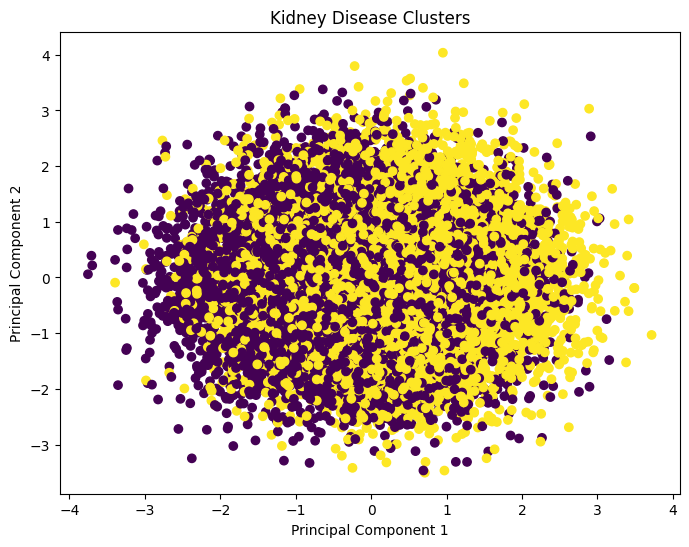

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Kidney Disease Clusters")
plt.show()

In [15]:
df_numeric.to_csv("kidney_disease_clustered.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [16]:
print(df.columns)

Index(['Age of the patient', 'Blood pressure (mm/Hg)',
       'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine',
       'Red blood cells in urine', 'Pus cells in urine',
       'Pus cell clumps in urine', 'Bacteria in urine',
       'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)',
       'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)',
       'Potassium level (mEq/L)', 'Hemoglobin level (gms)',
       'Packed cell volume (%)', 'White blood cell count (cells/cumm)',
       'Red blood cell count (millions/cumm)', 'Hypertension (yes/no)',
       'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)',
       'Appetite (good/poor)', 'Pedal edema (yes/no)', 'Anemia (yes/no)',
       'Estimated Glomerular Filtration Rate (eGFR)',
       'Urine protein-to-creatinine ratio', 'Urine output (ml/day)',
       'Serum albumin level', 'Cholesterol level',
       'Parathyroid hormone (PTH) level', 'Serum calcium level',
       'Serum phosphate level', 'Family hi

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

In [18]:
df = pd.read_csv("kidney_disease_dataset.csv")

df.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


In [19]:
df_numeric = df.select_dtypes(include=['int64','float64'])

print(df_numeric.shape)

(20538, 28)


In [20]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(20538, 2)


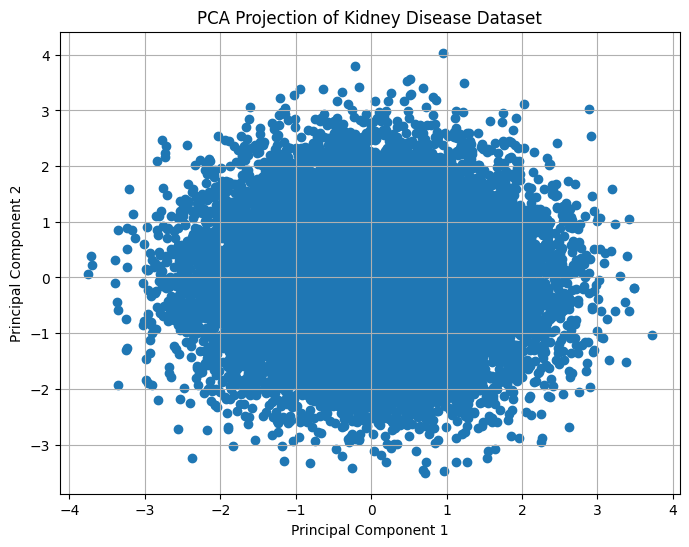

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA Projection of Kidney Disease Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

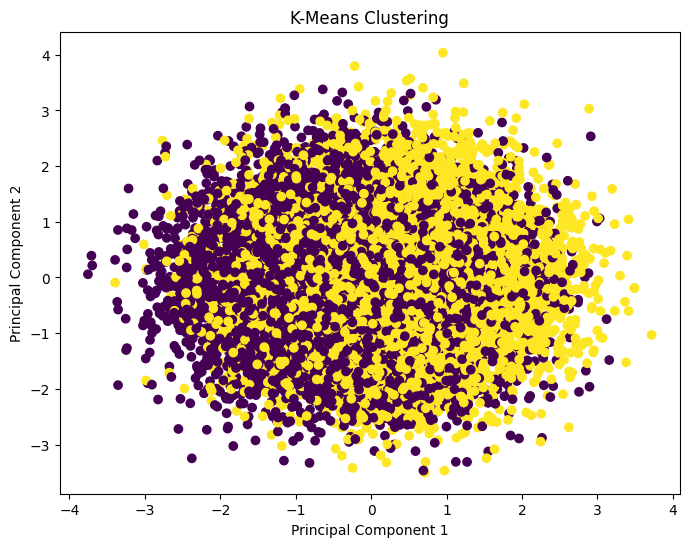

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [24]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

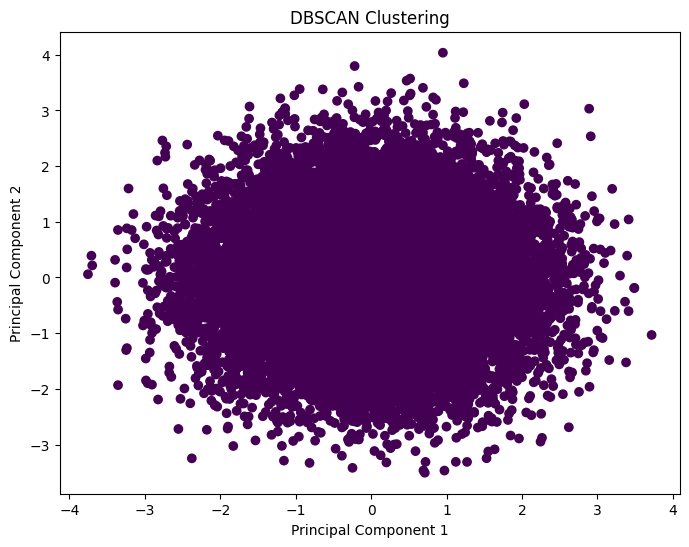

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels
)

plt.title("DBSCAN Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

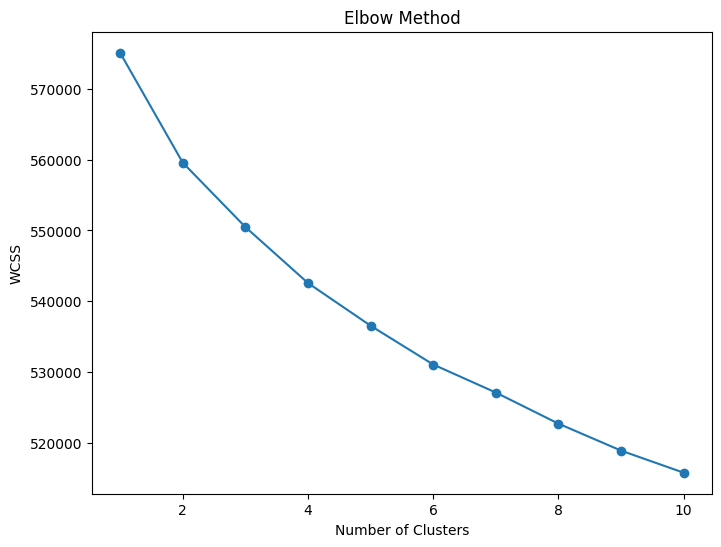

In [29]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

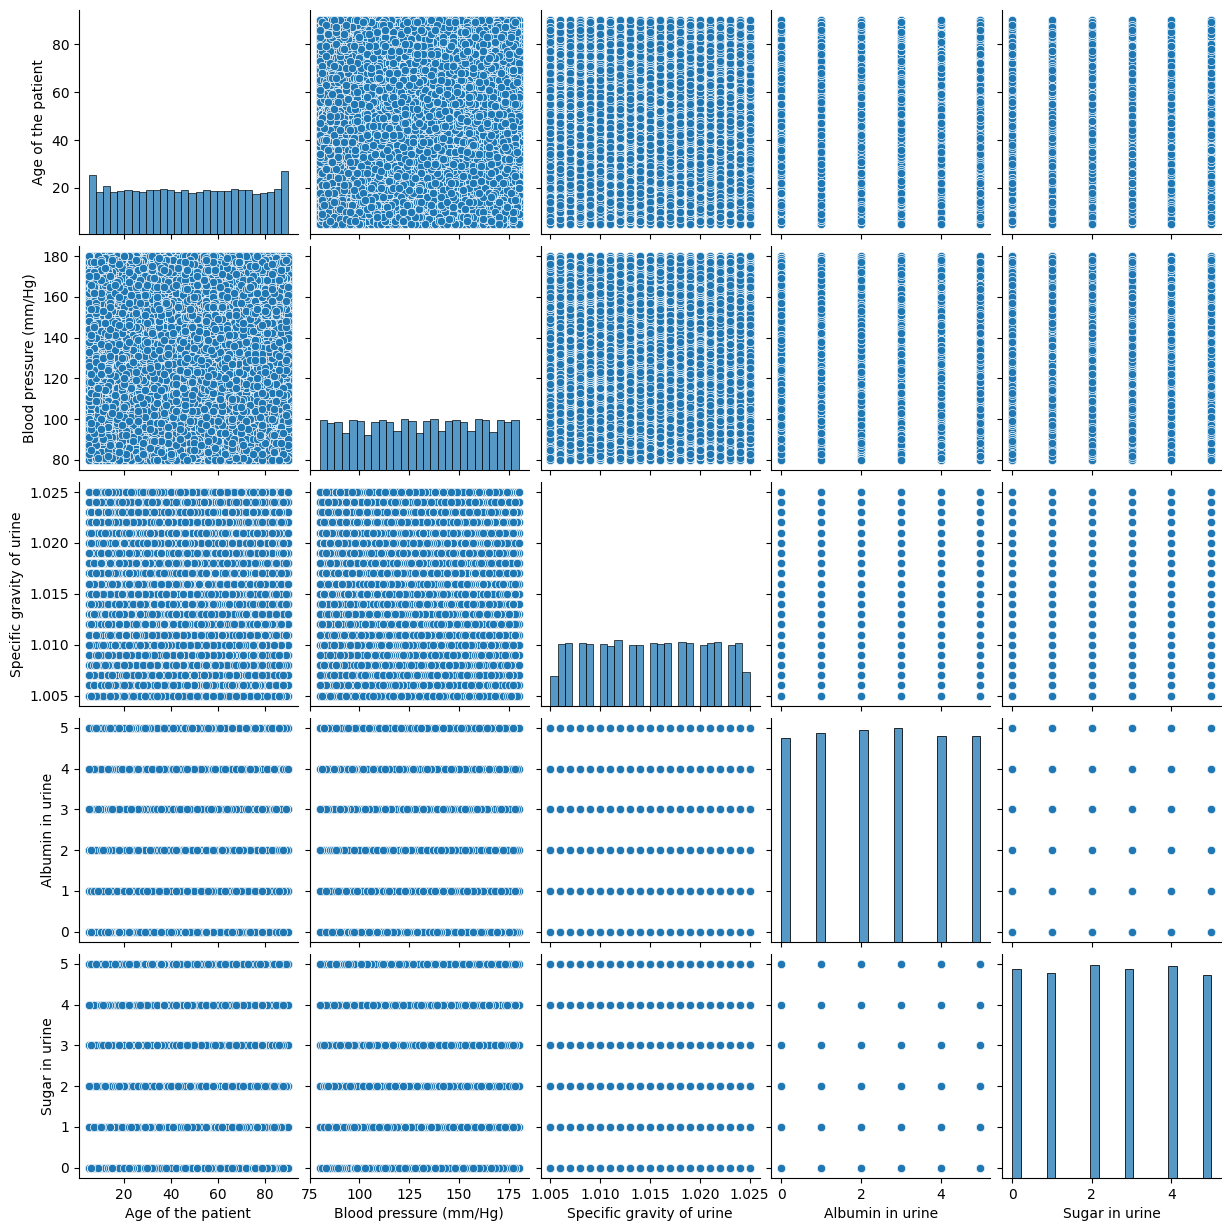

In [31]:
import seaborn as sns

sns.pairplot(
    df_numeric.iloc[:,0:5]
)

plt.show()

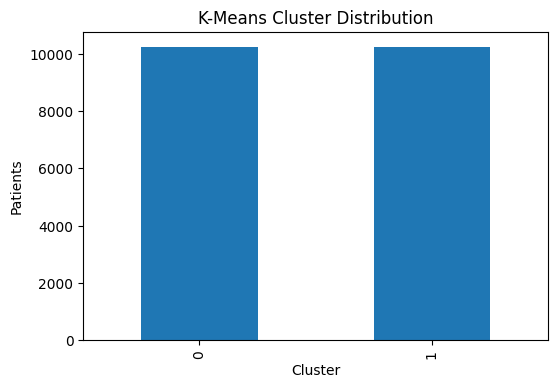

In [33]:
import pandas as pd

cluster_counts = pd.Series(kmeans_labels).value_counts()

plt.figure(figsize=(6,4))

cluster_counts.plot(kind='bar')

plt.title("K-Means Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Patients")

plt.show()

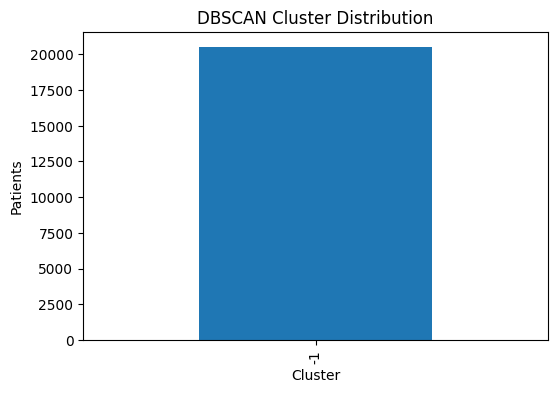

In [34]:
cluster_counts = pd.Series(dbscan_labels).value_counts()

plt.figure(figsize=(6,4))

cluster_counts.plot(kind='bar')

plt.title("DBSCAN Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Patients")

plt.show()

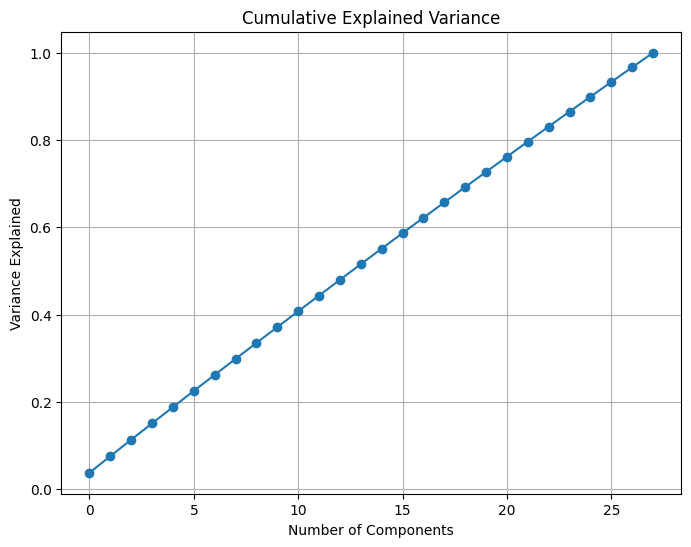

In [35]:
from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(8,6))

plt.plot(
    np.cumsum(
        pca_full.explained_variance_ratio_
    ),
    marker='o'
)

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance Explained")

plt.grid(True)

plt.show()

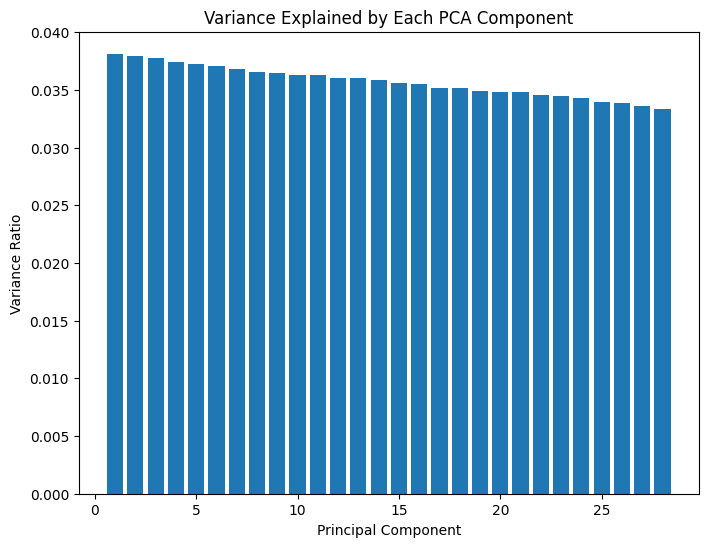

In [36]:
plt.figure(figsize=(8,6))

plt.bar(
    range(1, len(pca_full.explained_variance_ratio_)+1),
    pca_full.explained_variance_ratio_
)

plt.title("Variance Explained by Each PCA Component")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")

plt.show()

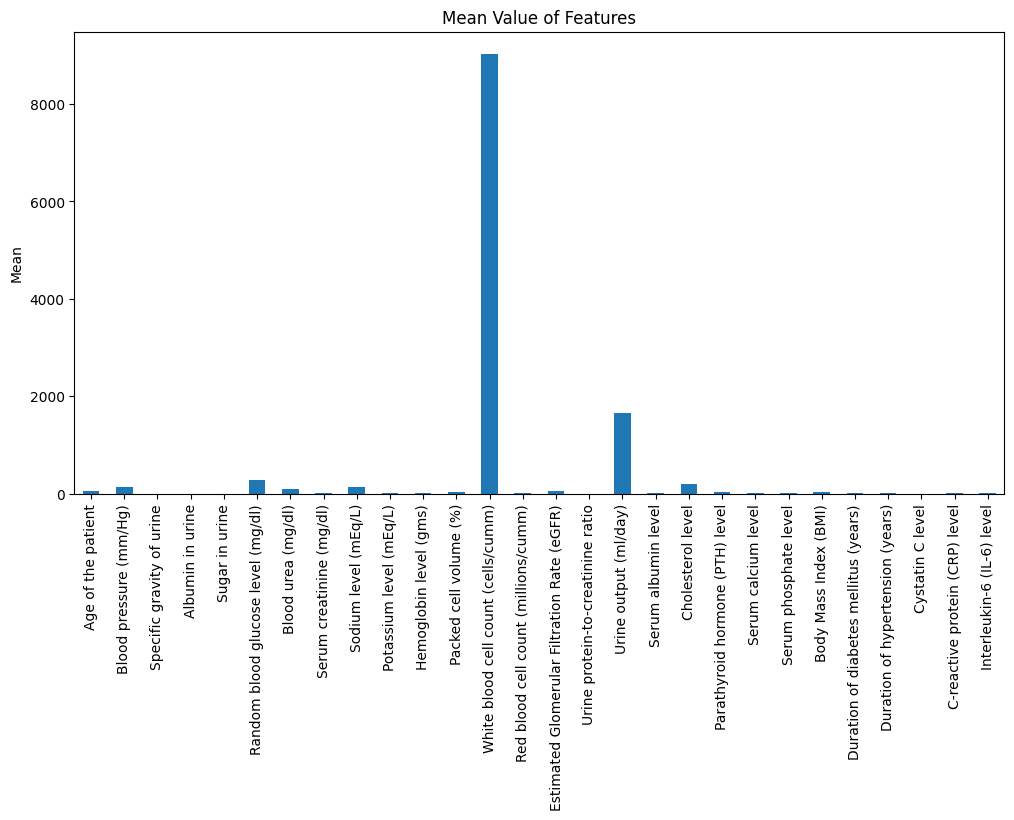

In [37]:
feature_means = df_numeric.mean()

plt.figure(figsize=(12,6))

feature_means.plot(kind='bar')

plt.title("Mean Value of Features")
plt.ylabel("Mean")

plt.show()

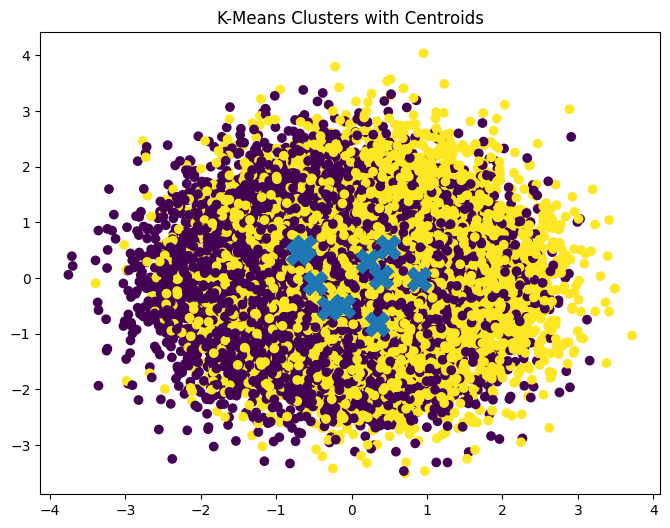

In [39]:
centers = kmeans.cluster_centers_

centers_pca = pca.transform(centers)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels
)

plt.scatter(
    centers_pca[:,0],
    centers_pca[:,1],
    marker='X',
    s=300
)

plt.title("K-Means Clusters with Centroids")

plt.show()

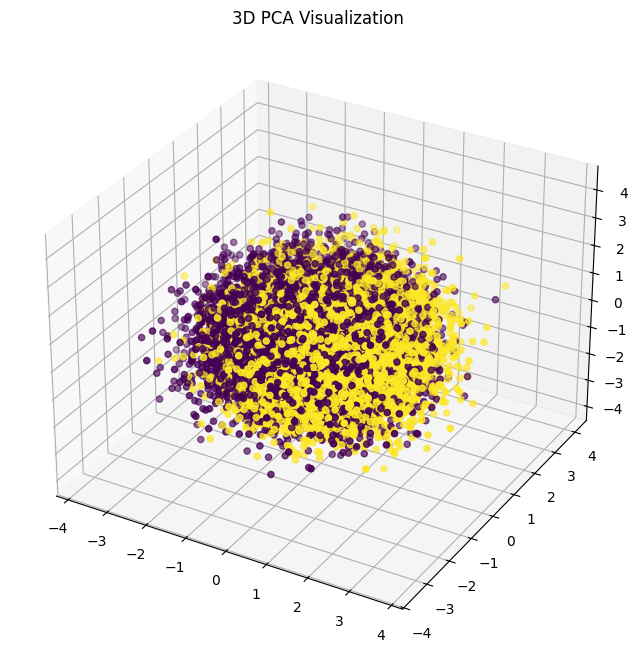

In [40]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)

X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=kmeans_labels
)

ax.set_title("3D PCA Visualization")

plt.show()